# TabulaX AutoFJ Sweep Results + LLM Call Analysis


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

TABULAX_ROOT = Path.cwd()
OUTPUTS_DIR = TABULAX_ROOT / "outputs"
ANALYSIS_DIR = TABULAX_ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

RUN_GLOB = "autofj_*_fixed10_edit_dist_gpt_classifier_sweep"

print("TabulaX root:", TABULAX_ROOT)
print("Outputs dir:", OUTPUTS_DIR)
print("Outputs exists:", OUTPUTS_DIR.exists())
print("Run glob:", RUN_GLOB)

TabulaX root: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX
Outputs dir: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\outputs
Outputs exists: True
Run glob: autofj_*_fixed10_edit_dist_gpt_classifier_sweep


In [2]:
def parse_output_folder(folder_name: str) -> dict:
    """
    Supported examples:
      autofj_Artwork_fixed10_edit_dist_gpt_classifier_sweep
      autofj_Artwork_fixed10_exact_gpt_classifier_sweep
      autofj_Artwork_qgram_gt_filtered_seed0_edit
      autofj_Artwork_qgram_gt_filtered_seed0_exact
    """
    info = {
        "run_folder": folder_name,
        "dataset": None,
        "example_selector": None,
        "example_size": None,
        "seed": None,
        "matching": None,
        "classification_type": None,
        "run_tag": None,
    }

    # Current sweep pattern.
    m = re.match(
        r"^autofj_(?P<dataset>.+)_fixed(?P<example_size>\d+)_(?P<matching>edit_dist|exact)_(?P<classification_type>gpt_classifier|golden|all_string)_(?P<run_tag>.+)$",
        folder_name,
    )
    if m:
        d = m.groupdict()
        info.update(d)
        info["example_selector"] = "fixed"
        info["example_size"] = int(info["example_size"])
        return info

    # Older manifest/qgram pattern.
    m = re.match(
        r"^autofj_(?P<dataset>.+?)_(?P<selector>.+?)_seed(?P<seed>\d+)_(?P<matching>edit|edit_dist|exact)(?:_(?P<run_tag>.+))?$",
        folder_name,
    )
    if m:
        d = m.groupdict()
        info["dataset"] = d["dataset"]
        info["example_selector"] = d["selector"]
        info["seed"] = int(d["seed"])
        info["matching"] = "edit_dist" if d["matching"] == "edit" else d["matching"]
        info["run_tag"] = d.get("run_tag")
        return info

    # Fallback.
    if folder_name.startswith("autofj_"):
        info["dataset"] = folder_name[len("autofj_"):]
    return info


def safe_json_load(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as e:
        print(f"Could not read {path}: {e}")
        return {}


def clean_key(value) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value)).strip("_")


def flatten_llm_summary(summary: dict) -> dict:
    out = {}

    base_keys = [
        "dataset", "ds_name", "ds_path", "model_name", "prompt_version", "basic_prompt",
        "example_size", "example_size_type", "matching_type", "classification_type",
        "total_events", "live_calls", "cache_hits", "success", "error",
        "total_duration_sec", "completed",
    ]
    for k in base_keys:
        out[f"llm_{k}"] = summary.get(k)

    token_usage = summary.get("token_usage") or {}
    for k, v in token_usage.items():
        out[f"llm_{k}"] = v

    stages = summary.get("stages") or {}
    for stage, vals in stages.items():
        stage_clean = clean_key(stage)
        for k, v in (vals or {}).items():
            out[f"llm_stage_{stage_clean}_{k}"] = v

    models = summary.get("models") or {}
    out["llm_models"] = ";".join(models.keys())
    return out


def preview(value, n=500):
    if value is None:
        return None
    if isinstance(value, (dict, list)):
        value = json.dumps(value, ensure_ascii=False, default=str)
    else:
        value = str(value)
    return value.replace("\n", "\\n")[:n]


def read_llm_calls(calls_path: Path, meta: dict) -> list[dict]:
    rows = []
    if not calls_path.exists():
        return rows

    with calls_path.open("r", encoding="utf-8", errors="replace") as f:
        for event_index, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                ev = json.loads(line)
            except Exception as e:
                rows.append({
                    **meta,
                    "event_index": event_index,
                    "parse_error": str(e),
                    "raw_line_preview": preview(line),
                })
                continue

            token_usage = ev.get("token_usage") or {}
            request_obj = ev.get("messages") or ev.get("request") or ev.get("prompt")
            response_obj = ev.get("response_text") or ev.get("response") or ev.get("completion")

            rows.append({
                **meta,
                "event_index": event_index,
                "timestamp": ev.get("timestamp"),
                "stage": ev.get("stage"),
                "table": ev.get("table"),
                "table_index": ev.get("table_index"),
                "provider": ev.get("provider"),
                "model": ev.get("model"),
                "model_name": ev.get("model_name"),
                "api_model": ev.get("api_model"),
                "api_model_effective": ev.get("api_model") or ev.get("model") or ev.get("model_name"),
                "cached": ev.get("cached"),
                "success": ev.get("success"),
                "error_message": ev.get("error_message"),
                "duration_sec": ev.get("duration_sec"),
                "prompt_tokens": token_usage.get("prompt_tokens"),
                "completion_tokens": token_usage.get("completion_tokens"),
                "total_tokens": token_usage.get("total_tokens"),
                "request_preview": preview(request_obj),
                "response_preview": preview(response_obj),
            })

    return rows


def normalize_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {"true", "1", "yes"}:
        return True
    if s in {"false", "0", "no"}:
        return False
    return pd.NA

## Load results

In [3]:
run_dirs = sorted([p for p in OUTPUTS_DIR.glob(RUN_GLOB) if p.is_dir()])
print("Matched run directories:", len(run_dirs))
for p in run_dirs:
    print(" -", p.name)

Matched run directories: 50
 - autofj_Amphibian_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_ArtificialSatellite_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Artwork_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Award_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_BasketballTeam_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Case_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_ChristianBishop_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_ClericalAdministrativeRegion_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Country_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Device_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Drug_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Election_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_Enzyme_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_EthnicGroup_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_FootballLeagueSeason_fixed10_edit_dist_gpt_classifier_sweep
 - autofj_FootballMatch_fixed10_edit_dist_gpt_classifier_sw

In [4]:
result_rows = []
event_rows = []
missing = []

for run_dir in run_dirs:
    res_path = run_dir / "_res.csv"
    summary_path = run_dir / "llm_summary.json"
    calls_path = run_dir / "llm_calls.jsonl"

    meta = parse_output_folder(run_dir.name)
    meta["output_dir"] = str(run_dir)
    meta["res_path"] = str(res_path)
    meta["llm_summary_path"] = str(summary_path) if summary_path.exists() else None
    meta["llm_calls_path"] = str(calls_path) if calls_path.exists() else None

    if not res_path.exists():
        missing.append({**meta, "missing_file": "_res.csv"})
        continue

    llm_summary = safe_json_load(summary_path)
    flat_llm = flatten_llm_summary(llm_summary)

    try:
        df = pd.read_csv(res_path)
    except Exception as e:
        missing.append({**meta, "missing_file": "_res.csv", "error": str(e)})
        continue

    for _, row in df.iterrows():
        item = {**meta, **flat_llm}
        item["table_id"] = row.get("id")
        item["class"] = row.get("class")
        item["P"] = row.get("P")
        item["R"] = row.get("R")
        item["F1"] = row.get("F1")
        item["correct"] = row.get("correct")
        item["n_test"] = row.get("len")
        item["gen_functions"] = row.get("gen_functions")
        item["avg_edit_dist"] = row.get("avg_edit_dist")
        item["avg_norm_edit_dist"] = row.get("avg_norm_edit_dist")
        item["time_sec"] = row.get("Time")
        item["detail_txt_path"] = str(run_dir / f"{row.get('id')}.txt")
        result_rows.append(item)

    event_rows.extend(read_llm_calls(calls_path, meta))

results = pd.DataFrame(result_rows)
llm_events = pd.DataFrame(event_rows)
missing_files = pd.DataFrame(missing)

numeric_cols = [
    "P", "R", "F1", "correct", "n_test", "gen_functions", "avg_edit_dist",
    "avg_norm_edit_dist", "time_sec", "example_size",
    "llm_total_events", "llm_live_calls", "llm_cache_hits", "llm_success",
    "llm_error", "llm_total_duration_sec", "llm_prompt_tokens",
    "llm_completion_tokens", "llm_total_tokens",
]
for c in numeric_cols:
    if c in results.columns:
        results[c] = pd.to_numeric(results[c], errors="coerce")

if {"correct", "n_test"}.issubset(results.columns):
    results["raw_correct_rate"] = results["correct"] / results["n_test"]

if not llm_events.empty:
    for c in ["duration_sec", "prompt_tokens", "completion_tokens", "total_tokens"]:
        if c in llm_events.columns:
            llm_events[c] = pd.to_numeric(llm_events[c], errors="coerce")
    llm_events["cached_bool"] = llm_events["cached"].map(normalize_bool)

print("Result rows:", len(results))
print("LLM events:", len(llm_events))
print("Missing/problem rows:", len(missing_files))

Result rows: 50
LLM events: 15108
Missing/problem rows: 0


## Main result table

In [5]:
display_cols = [
    "dataset", "example_selector", "example_size", "matching", "classification_type", "run_tag",
    "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate",
    "avg_edit_dist", "avg_norm_edit_dist", "time_sec",
    "llm_live_calls", "llm_cache_hits", "llm_total_tokens", "llm_models", "run_folder",
]
display_cols = [c for c in display_cols if c in results.columns]

cur = results.copy()
if not cur.empty:
    cur = cur.sort_values(["dataset", "matching", "classification_type", "run_folder"])
    display(cur[display_cols])
else:
    print("No results loaded. Check TABULAX_ROOT, OUTPUTS_DIR, and RUN_GLOB.")

if not missing_files.empty:
    display(missing_files)

,dataset,example_selector,example_size,matching,classification_type,run_tag,class,P,R,F1,correct,n_test,raw_correct_rate,avg_edit_dist,avg_norm_edit_dist,time_sec,llm_live_calls,llm_cache_hits,llm_total_tokens,llm_models,run_folder
0,Amphibian,fixed,10,edit_dist,gpt_classifier,sweep,General,0.369231,0.334204,0.350845,304,1151,0.264118,12.127715,0.543231,972.361887,1143,10,250545,openai/gpt-4o-mini,autofj_Amphibian_fixed10_edit_dist_gpt_classifier_sweep
1,ArtificialSatellite,fixed,10,edit_dist,gpt_classifier,sweep,General,0.620690,0.580645,0.600000,7,62,0.112903,6.580645,0.436726,44.737477,60,4,12158,openai/gpt-4o-mini,autofj_ArtificialSatellite_fixed10_edit_dist_gpt_classifier_sweep
2,Artwork,fixed,10,edit_dist,gpt_classifier,sweep,String,0.624434,0.592275,0.607930,58,235,0.246809,9.591489,0.311881,17.133400,2,0,957,openai/gpt-4o-mini,autofj_Artwork_fixed10_edit_dist_gpt_classifier_sweep
3,Award,fixed,10,edit_dist,gpt_classifier,sweep,General,0.716049,0.465241,0.564019,56,374,0.149733,8.427807,0.246683,266.458963,298,78,89257,openai/gpt-4o-mini,autofj_Award_fixed10_edit_dist_gpt_classifier_sweep
4,BasketballTeam,fixed,10,edit_dist,gpt_classifier,sweep,String,0.642857,0.576923,0.608108,0,156,0.000000,9.551282,0.438043,6.675701,2,0,907,openai/gpt-4o-mini,autofj_BasketballTeam_fixed10_edit_dist_gpt_classifier_sweep
5,Case,fixed,10,edit_dist,gpt_classifier,sweep,General,0.877841,0.835135,0.855956,154,370,0.416216,7.143243,0.153438,411.224732,354,18,99471,openai/gpt-4o-mini,autofj_Case_fixed10_edit_dist_gpt_classifier_sweep
6,ChristianBishop,fixed,10,edit_dist,gpt_classifier,sweep,General,0.547826,0.527197,0.537313,119,484,0.245868,9.322314,0.333789,407.246709,462,24,102883,openai/gpt-4o-mini,autofj_ChristianBishop_fixed10_edit_dist_gpt_classifier_sweep
7,ClericalAdministrativeRegion,fixed,10,edit_dist,gpt_classifier,sweep,General,0.633136,0.594444,0.613181,52,180,0.288889,10.122222,0.230275,144.633418,171,11,51923,openai/gpt-4o-mini,autofj_ClericalAdministrativeRegion_fixed10_edit_dist_gpt_classifier_sweep
8,Country,fixed,10,edit_dist,gpt_classifier,sweep,General,0.540856,0.494662,0.516729,58,281,0.206406,10.491103,0.411599,191.183295,262,21,57461,openai/gpt-4o-mini,autofj_Country_fixed10_edit_dist_gpt_classifier_sweep
9,Device,fixed,10,edit_dist,gpt_classifier,sweep,General,0.516181,0.494574,0.505146,59,648,0.091049,12.486111,0.479863,497.682586,620,30,130534,openai/gpt-4o-mini,autofj_Device_fixed10_edit_dist_gpt_classifier_sweep


## Export combined CSVs

The notebook writes three files:

```text
analysis/tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_results.csv
analysis/tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_llm_events.csv
analysis/tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_llm_stage_summary.csv
```


In [6]:
OUT_PREFIX = ANALYSIS_DIR / "tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep"

results_path = Path(str(OUT_PREFIX) + "_results.csv")
events_path = Path(str(OUT_PREFIX) + "_llm_events.csv")
stage_summary_path = Path(str(OUT_PREFIX) + "_llm_stage_summary.csv")

results.to_csv(results_path, index=False)
llm_events.to_csv(events_path, index=False)

if not llm_events.empty:
    def count_live(s):
        return int((s == False).fillna(False).sum())

    def count_cache(s):
        return int((s == True).fillna(False).sum())

    stage_summary = (
        llm_events
        .groupby(["dataset", "stage", "provider", "api_model_effective"], dropna=False)
        .agg(
            events=("event_index", "count"),
            live_calls=("cached_bool", count_live),
            cache_hits=("cached_bool", count_cache),
            duration_sec=("duration_sec", "sum"),
            prompt_tokens=("prompt_tokens", "sum"),
            completion_tokens=("completion_tokens", "sum"),
            total_tokens=("total_tokens", "sum"),
            successes=("success", lambda s: int((s == True).sum())),
            errors=("success", lambda s: int((s == False).sum())),
        )
        .reset_index()
        .sort_values(["dataset", "stage", "api_model_effective"])
    )
else:
    stage_summary = pd.DataFrame()

stage_summary.to_csv(stage_summary_path, index=False)

print("Wrote:", results_path)
print("Wrote:", events_path)
print("Wrote:", stage_summary_path)

Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_results.csv
Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_llm_events.csv
Wrote: c:\Users\Kai\Desktop\Files\New York University\VIDA\repo\TabulaX\analysis\tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_llm_stage_summary.csv


## LLM stage summary

This groups `llm_calls.jsonl` by dataset, stage, provider, and model. Use it to check which steps were live calls versus cache hits.


In [7]:
if not stage_summary.empty:
    display(stage_summary)
else:
    print("No LLM events loaded.")

,dataset,stage,provider,api_model_effective,events,live_calls,cache_hits,duration_sec,prompt_tokens,completion_tokens,total_tokens,successes,errors
0,Amphibian,classifier,openrouter,openai/gpt-4o-mini,1,1,0,0.672066,470,3,473,1,0
1,Amphibian,general_predict_bridge,openrouter,openai/gpt-4o-mini,1151,1141,10,757.235899,242263,7518,249781,1151,0
2,Amphibian,general_relation,openrouter,openai/gpt-4o-mini,1,1,0,0.842326,285,6,291,1,0
3,ArtificialSatellite,classifier,openrouter,openai/gpt-4o-mini,1,1,0,0.658863,435,3,438,1,0
4,ArtificialSatellite,general_predict_bridge,openrouter,openai/gpt-4o-mini,62,58,4,42.297985,11131,332,11463,62,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Venue,general_predict_bridge,openrouter,openai/gpt-4o-mini,374,348,26,226.320977,80744,2514,83258,374,0
140,Venue,general_relation,openrouter,openai/gpt-4o-mini,1,1,0,0.646854,289,9,298,1,0
141,Wrestler,classifier,openrouter,openai/gpt-4o-mini,1,1,0,0.581312,421,4,425,1,0
142,Wrestler,general_predict_bridge,openrouter,openai/gpt-4o-mini,454,439,15,297.126877,74223,1775,75998,454,0


## OpenRouter / model check

In [8]:
if llm_events.empty:
    print("No LLM events loaded.")
else:
    live_events = llm_events[llm_events["cached_bool"] == False].copy()

    print("Live event model/provider counts:")
    if live_events.empty:
        print("No live events found. This usually means caches were reused or logs are missing cached flags.")
    else:
        display(
            live_events
            .groupby(["provider", "api_model"], dropna=False)
            .size()
            .reset_index(name="events")
            .sort_values("events", ascending=False)
        )

        suspicious = live_events[
            (live_events["provider"] != "openrouter") |
            (live_events["api_model"] != "openai/gpt-4o-mini")
        ].copy()

        if suspicious.empty:
            print("All live calls use provider=openrouter and api_model=openai/gpt-4o-mini.")
        else:
            print("Check these live events; they do not match the expected provider/model:")
            display(suspicious[["dataset", "stage", "provider", "api_model", "model", "model_name", "cached", "success", "duration_sec"]])

Live event model/provider counts:


,provider,api_model,events
0,openrouter,openai/gpt-4o-mini,14158


All live calls use provider=openrouter and api_model=openai/gpt-4o-mini.


## LLM event details

In [9]:
event_cols = [
    "dataset", "event_index", "stage", "table", "provider", "api_model", "model",
    "cached", "success", "duration_sec", "prompt_tokens", "completion_tokens", "total_tokens",
    "response_preview", "request_preview",
]
event_cols = [c for c in event_cols if c in llm_events.columns]

if not llm_events.empty:
    display(llm_events[event_cols].sort_values(["dataset", "event_index"]))
else:
    print("No LLM event rows loaded.")

,dataset,event_index,stage,table,provider,api_model,model,cached,success,duration_sec,prompt_tokens,completion_tokens,total_tokens,response_preview,request_preview
0,Amphibian,1,classifier,Amphibian,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.672066,470,3,473,Class: General,"[{""role"": ""user"", ""content"": ""Classify the following data transformations into one of the classes.\nClasses: [`String`, `Numbers`, `Algorithmic`, `General`]\n\nString: When The values on both side..."
1,Amphibian,2,general_relation,Amphibian,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.842326,285,6,291,Common Name to Scientific Name,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. Find what is the relationship between the source and target values.\nFormat the answer as [type of source] to [type of..."
2,Amphibian,3,general_predict_bridge,Amphibian,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.545519,211,6,217,Glandular Toadlet,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common Name and target values are Scientific Name.\nPlease transform the given value with respec..."
3,Amphibian,4,general_predict_bridge,Amphibian,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.776650,212,7,219,Rhinella marsupialis,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common Name and target values are Scientific Name.\nPlease transform the given value with respec..."
4,Amphibian,5,general_predict_bridge,Amphibian,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.701134,213,9,222,Osteocephalus taurinus,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Common Name and target values are Scientific Name.\nPlease transform the given value with respec..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15103,Wrestler,452,general_predict_bridge,Wrestler,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.396824,166,2,168,Kazma,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional Wrestler and target values are Ring Name.\nPlease transform the given value with re..."
15104,Wrestler,453,general_predict_bridge,Wrestler,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.698571,166,3,169,Tim Burke,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional Wrestler and target values are Ring Name.\nPlease transform the given value with re..."
15105,Wrestler,454,general_predict_bridge,Wrestler,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.492775,162,2,164,Crash Holly,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional Wrestler and target values are Ring Name.\nPlease transform the given value with re..."
15106,Wrestler,455,general_predict_bridge,Wrestler,openrouter,openai/gpt-4o-mini,gpt-4o-mini-2024-07-18,False,True,0.823053,162,3,165,Melanie Cruise,"[{""role"": ""user"", ""content"": ""You are given a set of source and target pairs. The source values are Professional Wrestler and target values are Ring Name.\nPlease transform the given value with re..."


## Performance plots


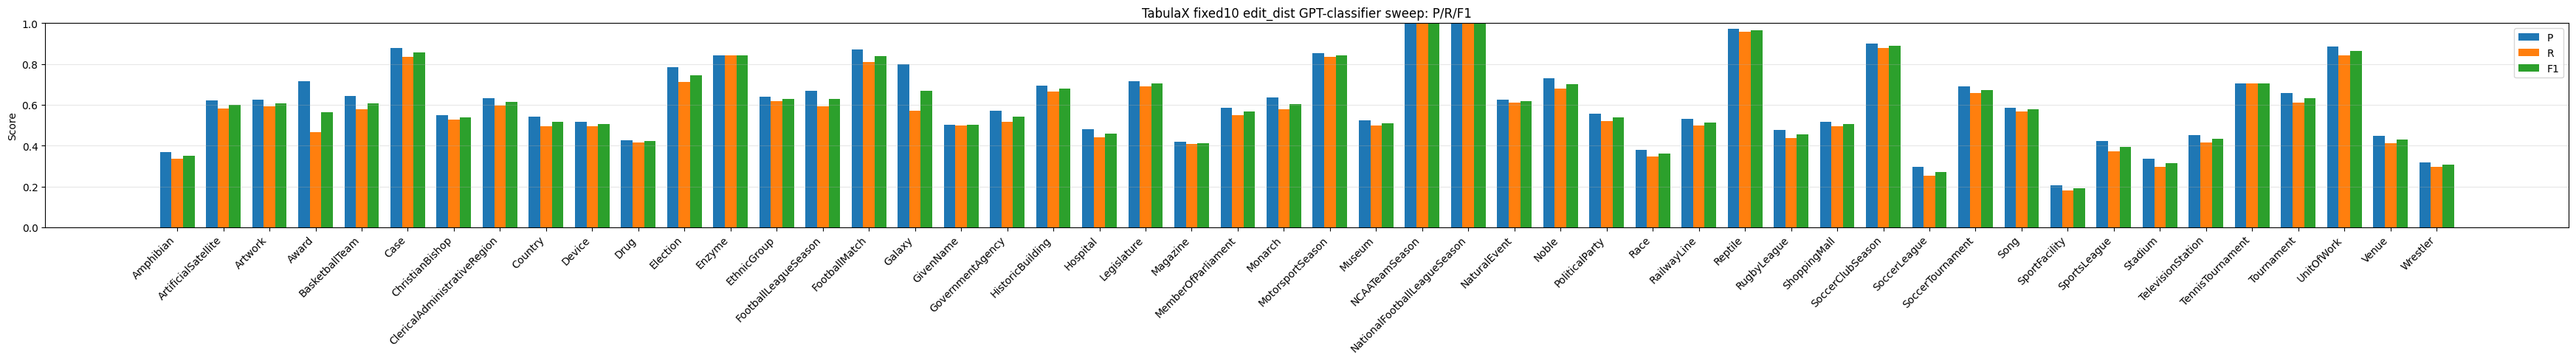

In [10]:
def require_results(df):
    if df.empty:
        print("No rows to plot.")
        return False
    return True


def plot_prf_by_dataset(df):
    if not require_results(df):
        return

    d = df.sort_values("dataset").copy()
    labels = d["dataset"].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.7), 5))
    for i, metric in enumerate(["P", "R", "F1"]):
        ax.bar(x + (i - 1) * width, d[metric].values, width, label=metric)

    ax.set_title("TabulaX fixed10 edit_dist GPT-classifier sweep: P/R/F1")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_prf_by_dataset(cur)

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


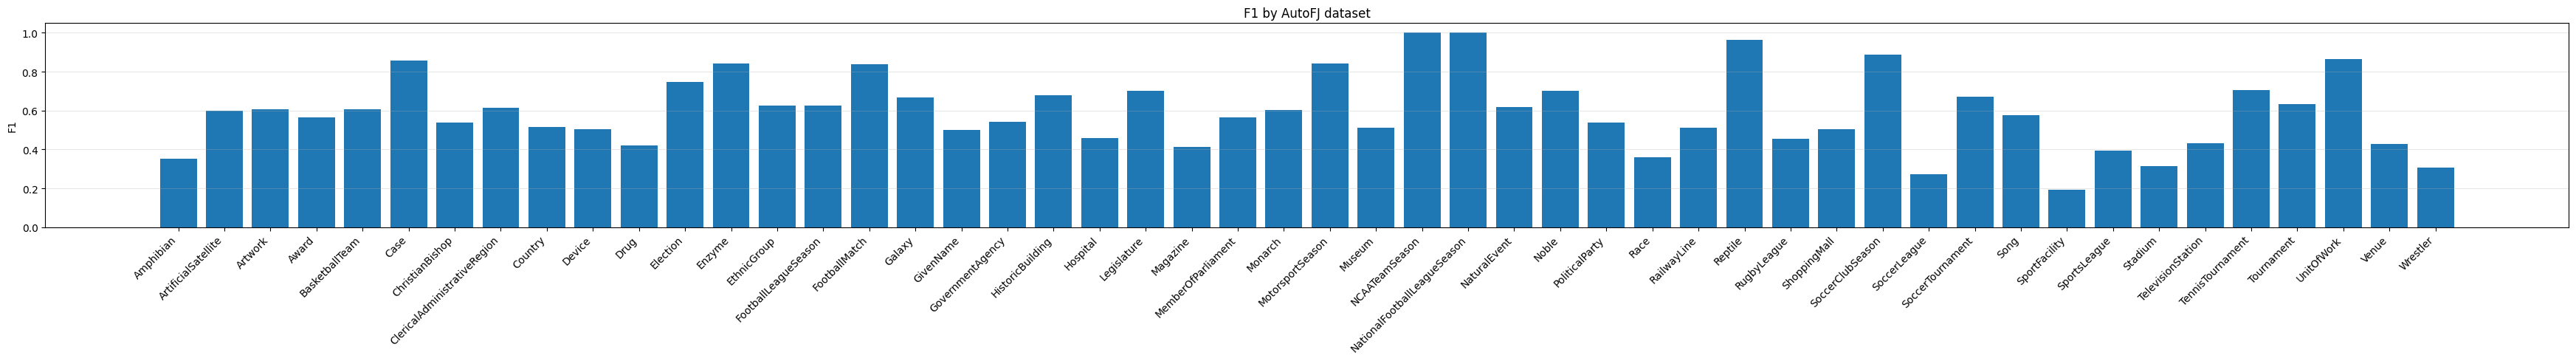

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


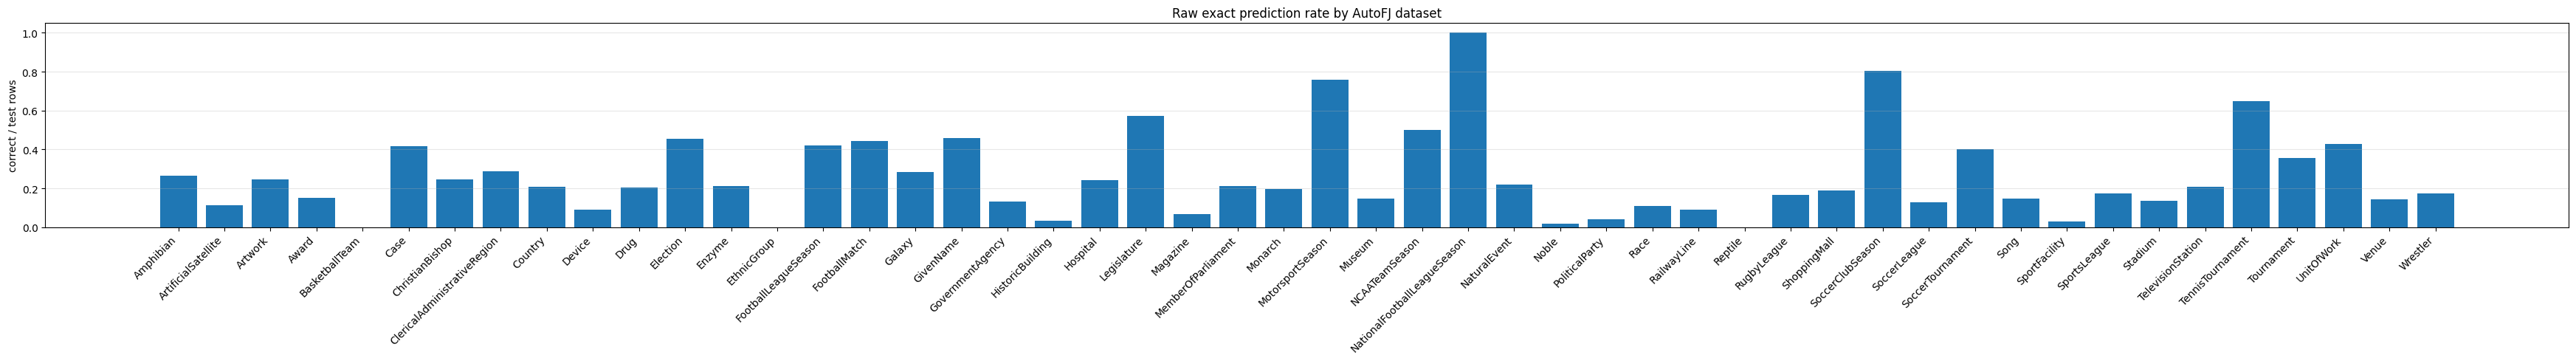

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


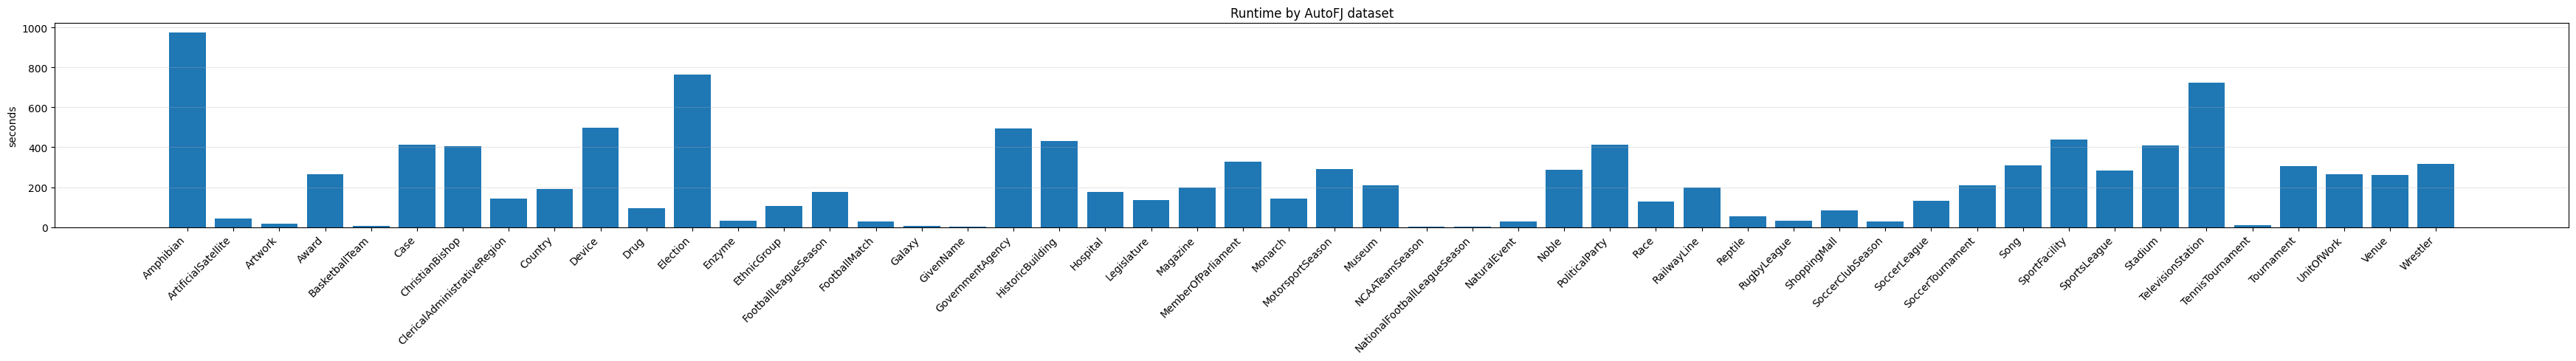

In [11]:
def plot_single_metric(df, metric, title, ylabel=None):
    if not require_results(df):
        return
    if metric not in df.columns:
        print(f"Missing column: {metric}")
        return

    d = df.sort_values("dataset").copy()
    fig, ax = plt.subplots(figsize=(max(10, len(d) * 0.7), 5))
    ax.bar(d["dataset"].astype(str), d[metric])
    ax.set_title(title)
    ax.set_ylabel(ylabel or metric)
    ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_single_metric(cur, "F1", "F1 by AutoFJ dataset", "F1")
plot_single_metric(cur, "raw_correct_rate", "Raw exact prediction rate by AutoFJ dataset", "correct / test rows")
plot_single_metric(cur, "time_sec", "Runtime by AutoFJ dataset", "seconds")

## LLM cost/call plots

These use the aggregated values in `llm_summary.json`. Token counts are only as complete as the LLM logging data returned by the provider/cache.

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


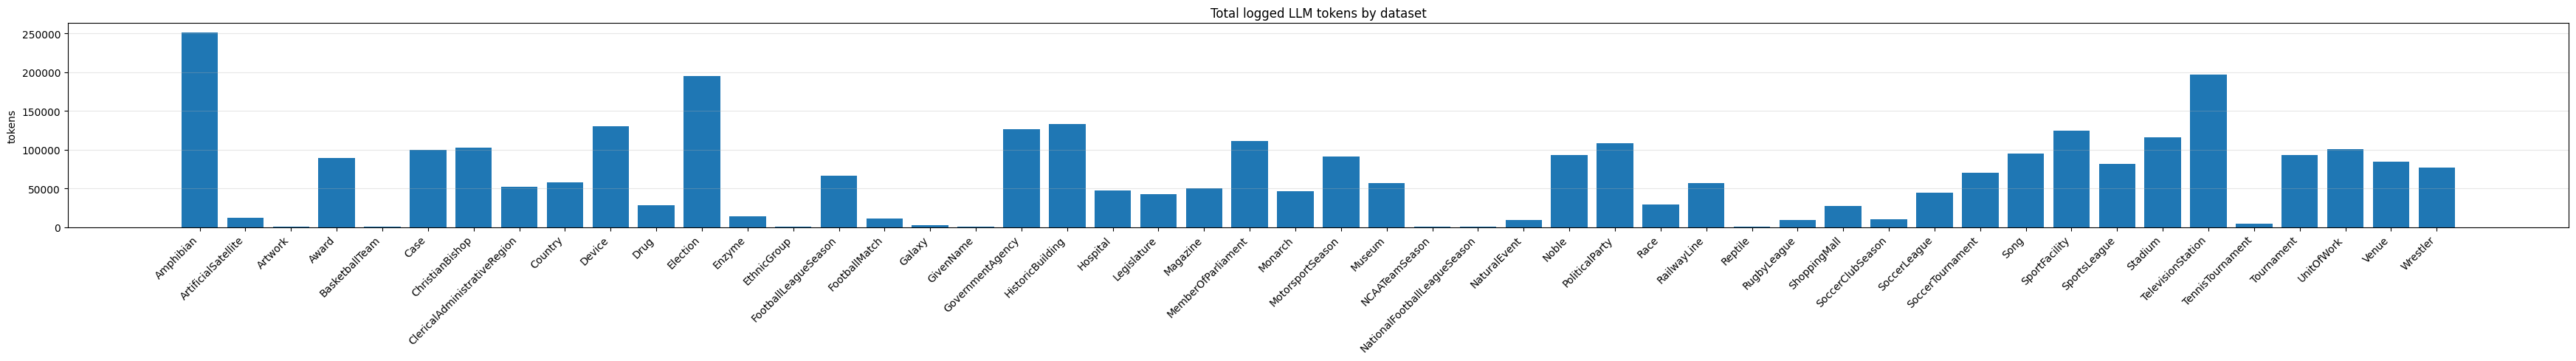

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


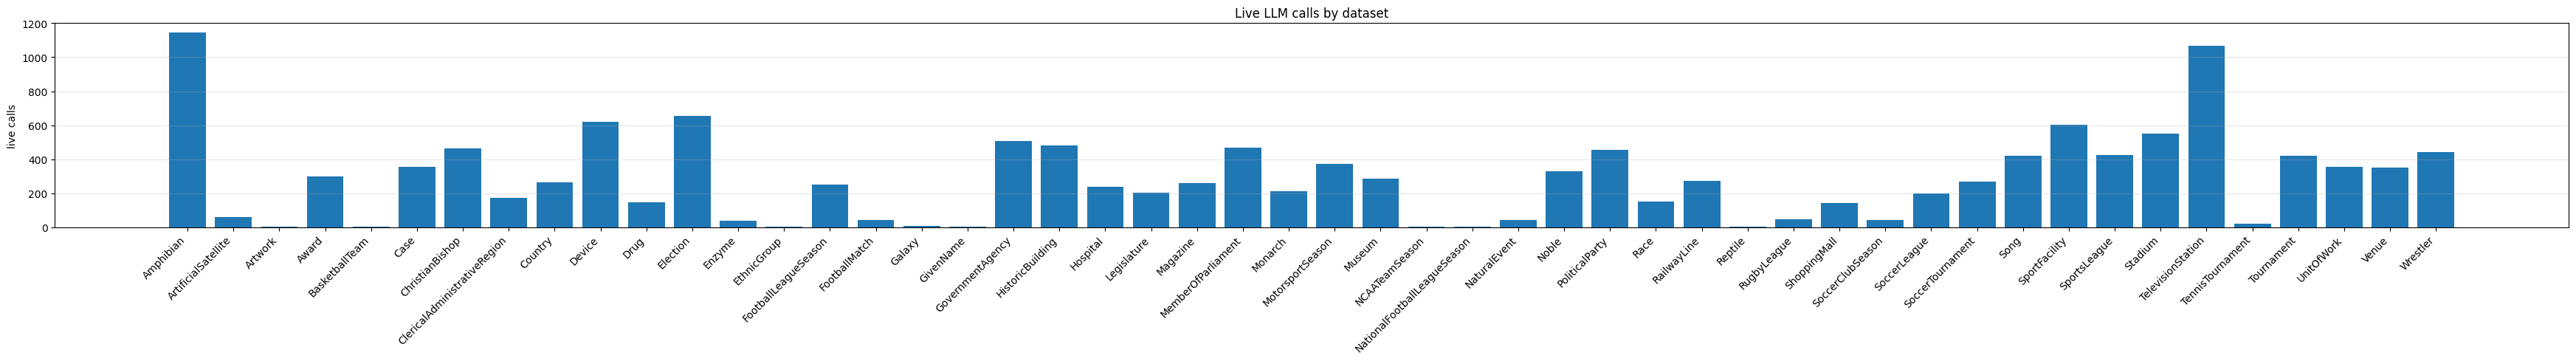

C:\Users\Kai\AppData\Local\Temp\ipykernel_35844\2491703767.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d["dataset"].astype(str), rotation=45, ha="right")


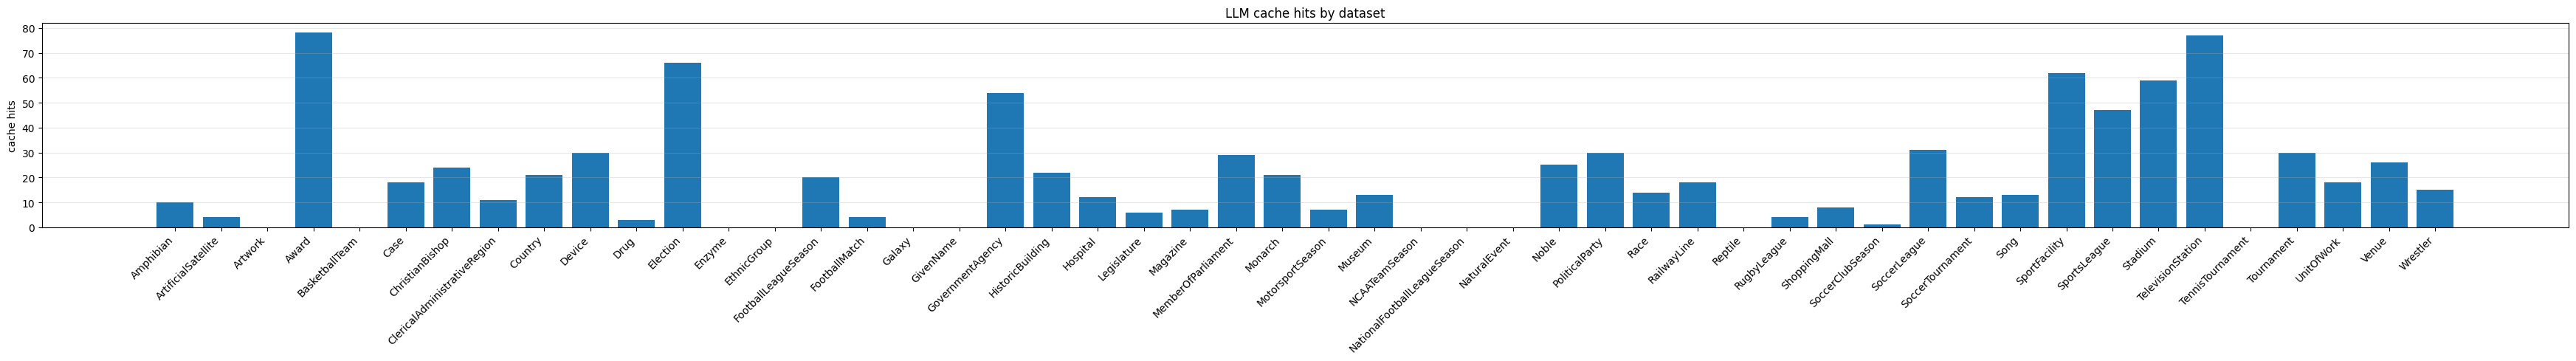

In [12]:
plot_single_metric(cur, "llm_total_tokens", "Total logged LLM tokens by dataset", "tokens")
plot_single_metric(cur, "llm_live_calls", "Live LLM calls by dataset", "live calls")
plot_single_metric(cur, "llm_cache_hits", "LLM cache hits by dataset", "cache hits")

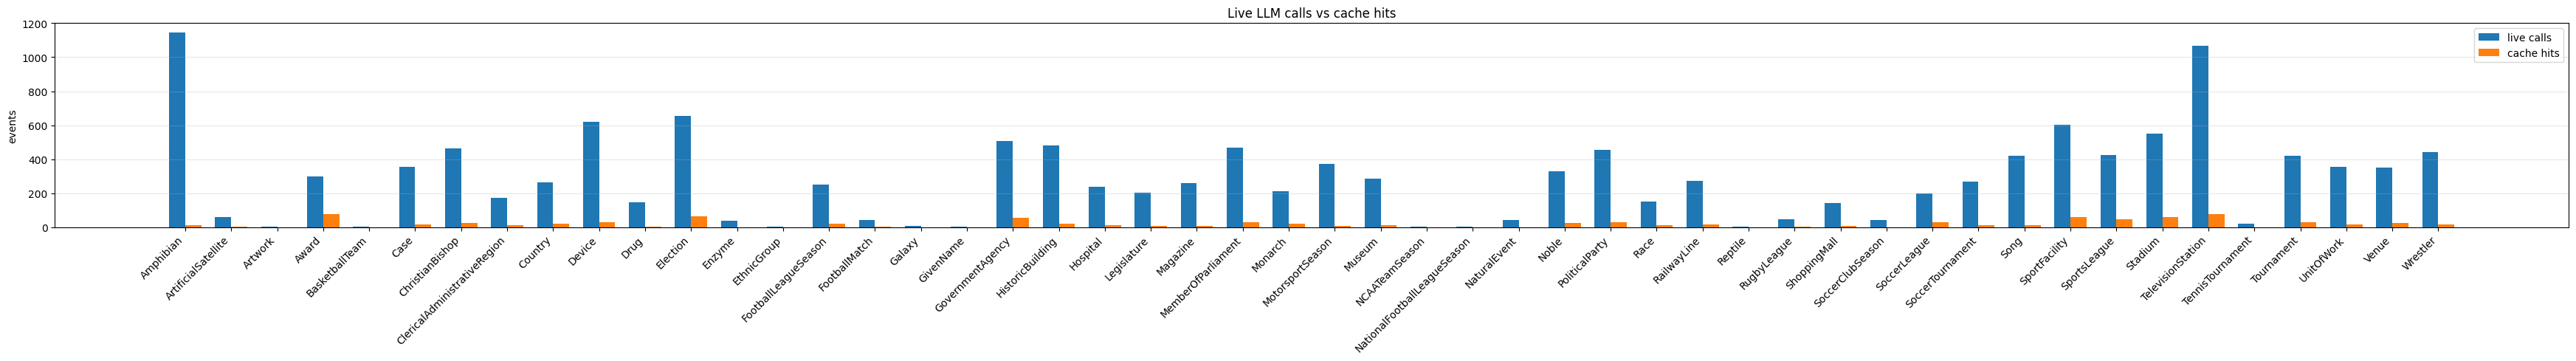

In [13]:
def plot_live_vs_cache(df):
    needed = {"dataset", "llm_live_calls", "llm_cache_hits"}
    if df.empty or not needed.issubset(df.columns):
        print("Need dataset, llm_live_calls, and llm_cache_hits columns.")
        return

    d = df.sort_values("dataset").copy()
    labels = d["dataset"].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.7), 5))
    ax.bar(x - width / 2, d["llm_live_calls"], width, label="live calls")
    ax.bar(x + width / 2, d["llm_cache_hits"], width, label="cache hits")
    ax.set_title("Live LLM calls vs cache hits")
    ax.set_ylabel("events")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_live_vs_cache(cur)

## Best / worst datasets by F1


In [14]:
if not cur.empty:
    rank_cols = ["dataset", "class", "P", "R", "F1", "correct", "n_test", "raw_correct_rate", "time_sec", "llm_live_calls", "llm_total_tokens", "run_folder"]
    rank_cols = [c for c in rank_cols if c in cur.columns]
    display(cur[rank_cols].sort_values("F1", ascending=False))
else:
    print("No rows loaded.")

,dataset,class,P,R,F1,correct,n_test,raw_correct_rate,time_sec,llm_live_calls,llm_total_tokens,run_folder
29,NCAATeamSeason,String,1.000000,1.000000,1.000000,12,24,0.500000,4.593371,2,878,autofj_NCAATeamSeason_fixed10_edit_dist_gpt_classifier_sweep
27,NationalFootballLeagueSeason,General,1.000000,1.000000,1.000000,1,1,1.000000,1.852335,3,930,autofj_NationalFootballLeagueSeason_fixed10_edit_dist_gpt_classifier_sweep
34,Reptile,String,0.974074,0.956364,0.965138,0,552,0.000000,55.125583,2,966,autofj_Reptile_fixed10_edit_dist_gpt_classifier_sweep
37,SoccerClubSeason,General,0.900000,0.878049,0.888889,33,41,0.804878,30.067409,42,10608,autofj_SoccerClubSeason_fixed10_edit_dist_gpt_classifier_sweep
47,UnitOfWork,General,0.886364,0.843243,0.864266,158,370,0.427027,263.749112,354,100482,autofj_UnitOfWork_fixed10_edit_dist_gpt_classifier_sweep
5,Case,General,0.877841,0.835135,0.855956,154,370,0.416216,411.224732,354,99471,autofj_Case_fixed10_edit_dist_gpt_classifier_sweep
25,MotorsportSeason,General,0.851752,0.835979,0.843792,287,378,0.759259,292.519197,373,91563,autofj_MotorsportSeason_fixed10_edit_dist_gpt_classifier_sweep
12,Enzyme,General,0.842105,0.842105,0.842105,8,38,0.210526,30.821596,40,13793,autofj_Enzyme_fixed10_edit_dist_gpt_classifier_sweep
15,FootballMatch,General,0.871795,0.809524,0.839506,19,43,0.441860,29.516764,41,10761,autofj_FootballMatch_fixed10_edit_dist_gpt_classifier_sweep
11,Election,General,0.784615,0.711297,0.746159,325,717,0.453278,763.048527,653,195205,autofj_Election_fixed10_edit_dist_gpt_classifier_sweep


## Inspect detailed `.txt` output for one dataset

Each run folder has a `DatasetName.txt` file with generated functions, details, processed table rows, and predictions. Use the helper below to preview one of those files directly inside the notebook.


In [15]:
def show_detail(dataset_name: str, max_chars: int = 6000):
    if cur.empty:
        print("No results loaded.")
        return

    matches = cur[cur["dataset"].astype(str).str.lower() == dataset_name.lower()]
    if matches.empty:
        print("Available datasets:", sorted(cur["dataset"].dropna().astype(str).unique()))
        return

    path = Path(matches.iloc[0]["detail_txt_path"])
    print("Detail path:", path)
    if not path.exists():
        print("File does not exist.")
        return

    text = path.read_text(encoding="utf-8", errors="replace")
    print(text[:max_chars])
    if len(text) > max_chars:
        print(f"\n... truncated at {max_chars} characters ...")

# Example:
# show_detail("Artwork")

In [ ]:
from pathlib import Path
import pandas as pd

# Use live API calls as "number of LLM calls".
# If you want cache hits included too, replace "llm_live_calls" with "llm_total_events".
concise = results.copy()

# Pick dataset column robustly
dataset_col = "dataset" if "dataset" in concise.columns else "dataset_from_folder"

concise_results = concise[[dataset_col, "P", "R", "llm_live_calls"]].rename(columns={
    dataset_col: "dataset_name",
    "P": "precision",
    "R": "recall",
    "llm_live_calls": "num_llm_calls",
})

concise_results = concise_results.sort_values("dataset_name").reset_index(drop=True)

out_path = Path("analysis/tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_concise_results.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
concise_results.to_csv(out_path, index=False)

print(f"Wrote: {out_path}")
display(concise_results)

Wrote: analysis\tabulax_autofj_fixed10_edit_dist_gpt_classifier_sweep_concise_results.csv


,dataset_name,precision,recall,num_llm_calls
0,Amphibian,0.369231,0.334204,1143
1,ArtificialSatellite,0.620690,0.580645,60
2,Artwork,0.624434,0.592275,2
3,Award,0.716049,0.465241,298
4,BasketballTeam,0.642857,0.576923,2
5,Case,0.877841,0.835135,354
6,ChristianBishop,0.547826,0.527197,462
7,ClericalAdministrativeRegion,0.633136,0.594444,171
8,Country,0.540856,0.494662,262
9,Device,0.516181,0.494574,620
